<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/ewaluacja_i_wyniki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Moduł 3: Ewaluacja i analiza wyników

## Klasyfikacja tematyczna krótkich tekstów w języku polskim

W tym modelu:
1. Porównujemy ilościowo oba podejścia (klasyczne vs Transformer)
2. Przeprowadzamy analizę błędów
3. Identyfikujemy typowe pomyłki modeli z przykładami
4. Formułujemy wnioski

In [11]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Wczytanie pliku CSV z predykcjami z dysku
file_path = '/content/drive/MyDrive/test_predictions.csv'
results_df = pd.read_csv(file_path)

test_df = pd.DataFrame({'sentence_cleaned': results_df['text'].values, 'label': results_df['label'].values})
y_true = results_df['label'].values
y_pred_classic = results_df['pred_classic'].values
y_pred_transformer = results_df['pred_transformer'].values

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd

# Zebranie wyników w tabelę
results_df = pd.DataFrame({
    'Tekst': test_df['sentence_cleaned'].values,
    'Prawdziwa_Kategoria': test_df['label'].values,
    'Przewidywana_Kategoria': y_pred_transformer
})

# Filtrowanie tylko błędnych predykcji
errors_df = results_df[results_df['Prawdziwa_Kategoria'] != results_df['Przewidywana_Kategoria']]

print(" PRZYKŁADOWE POMYŁKI MODELU HERBERT ")
print(f"Łączna liczba pomyłek: {len(errors_df)} na {len(test_df)} testowanych przypadków.\n")

# 5 losowych pomyłek
pd.set_option('display.max_colwidth', None)

# Predykcje obu modeli w jedną tabelę
comparison_df = pd.DataFrame({
    'Tekst_Oryginalny': test_df['sentence_cleaned'].values,
    'Prawdziwa_Kategoria': test_df['label'].values,
    'Predykcja_SVM': y_pred_classic,
    'Predykcja_HerBERT': y_pred_transformer
})

# Przypadki, gdzie SVM poległ, a HerBERT zgadł idealnie
svm_failed_herbert_saved = comparison_df[
    (comparison_df['Prawdziwa_Kategoria'] != comparison_df['Predykcja_SVM']) &
    (comparison_df['Prawdziwa_Kategoria'] == comparison_df['Predykcja_HerBERT'])
]

print(f"HerBERT uratował {len(svm_failed_herbert_saved)} przypadków, z którymi SVM sobie nie poradził!\n")
print("Oto 3 przykłady tekstów, gdzie rozumienie kontekstu było kluczowe:")
display(svm_failed_herbert_saved.sample(3))
display(errors_df.sample(5))

 PRZYKŁADOWE POMYŁKI MODELU HERBERT 
Łączna liczba pomyłek: 1792 na 8001 testowanych przypadków.

HerBERT uratował 1203 przypadków, z którymi SVM sobie nie poradził!

Oto 3 przykłady tekstów, gdzie rozumienie kontekstu było kluczowe:


,Tekst_Oryginalny,Prawdziwa_Kategoria,Predykcja_SVM,Predykcja_HerBERT
6015,KE opublikowała raport po audycie w Polsce; kontrole uboju nieskuteczne.,2,5,2
3081,Dr hab. P. Szlanta: Polska okazała się beneficjentem Traktatu Wersalskiego.,1,3,1
5421,"Gdyby wiedział, jaka kara go czeka, być może dwa razy zastanowiłby się nad swoim planem..",1,0,1


,Tekst,Prawdziwa_Kategoria,Przewidywana_Kategoria
2624,"Co to znaczy ""produkcja zwierząt""?",1,2
253,Larwy w Białych Michałkach WAWEL.,2,0
3274,"Wiosna za pasem, więc warto mieć w tyle głowy (informację, nie kleszcza",3,6
6980,"""Z ziemi podlaskiej"" to fabularyzowany film dokumentalny opowiadający o poświęceniu tysięcy unickich rodzin, które w drugiej połowie XIX wieku na południowym Podlasiu cierpiały niewyobrażalne z dzisiejszej perspektywy męki z rąk żołnierzy carskich i kozackich sotni.",0,1
3817,Niestety umiejętność ta może wyginąć na zawsze,2,7


KATEGORIE BŁĘDÓW 
error_type
oba poprawne                5006
oba błędne                  1367
tylko klasyczny błędny      1203
tylko transformer błędny     425
Name: count, dtype: int64

Procent pełnej zgodności obu modeli (oba poprawne): 62.6%


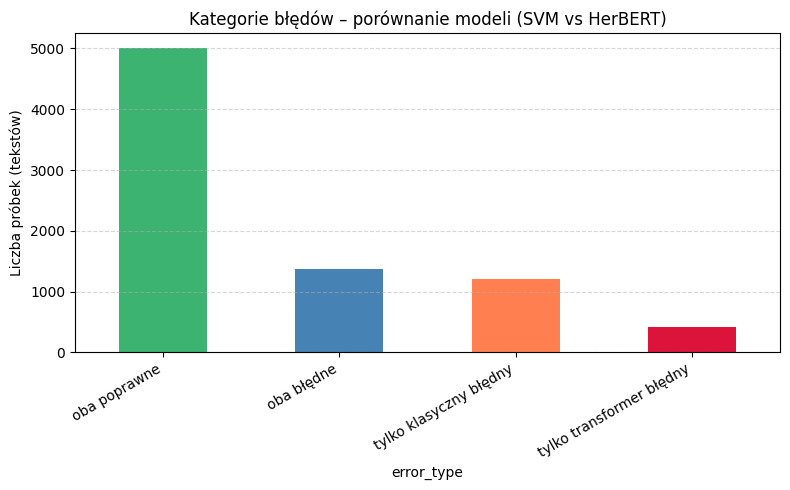

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame({
    'sentence_cleaned': test_df['sentence_cleaned'].values,
    'label': test_df['label'].values,              # "y_true"
    'y_pred_classic': y_pred_classic,              # Wynik z modelu SVM
    'y_pred_transformer': y_pred_transformer       # Wynik z modelu HerBERT
})

# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (results_df["label"] == results_df["y_pred_classic"])
results_df["transformer_correct"] = (results_df["label"] == results_df["y_pred_transformer"])

# Kategorie błędów
results_df["error_type"] = "oba poprawne"

results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"

results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"

results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

# Wyświetlanie statystyk tekstowych
print("KATEGORIE BŁĘDÓW ")
error_counts = results_df["error_type"].value_counts()
print(error_counts)

procent_zgodnosci = (error_counts.get('oba poprawne', 0)) / len(results_df) * 100
print(f"\nProcent pełnej zgodności obu modeli (oba poprawne): {procent_zgodnosci:.1f}%")

# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]

error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)

ax.set_title("Kategorie błędów – porównanie modeli (SVM vs HerBERT)", fontsize=12)
ax.set_ylabel("Liczba próbek (tekstów)", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# Odtworzenie bazy wynikowej (zabezpieczenie przed resetem indeksów)
results_df = pd.DataFrame({
    'Tekst': test_df['sentence_cleaned'].values,
    'Prawdziwa_Klasa': test_df['label'].values,
    'Predykcja_SVM': y_pred_classic,
    'Predykcja_HerBERT': y_pred_transformer
})

# Słownik do mapowania numerów na czytelne nazwy
kategorie_map = {
    0: 'film', 1: 'historia', 2: 'jedzenie', 3: 'medycyna',
    4: 'motoryzacja', 5: 'praca', 6: 'sport', 7: 'technologia'
}

# Mapujemy numery na nazwy słowne
results_df['Prawdziwa_Kategoria'] = results_df['Prawdziwa_Klasa'].map(kategorie_map)
results_df['Klasyfikacja_SVM'] = results_df['Predykcja_SVM'].map(kategorie_map)
results_df['Klasyfikacja_HerBERT'] = results_df['Predykcja_HerBERT'].map(kategorie_map)

# Flagi poprawności
results_df["classic_correct"] = (results_df["Prawdziwa_Klasa"] == results_df["Predykcja_SVM"])
results_df["transformer_correct"] = (results_df["Prawdziwa_Klasa"] == results_df["Predykcja_HerBERT"])

# Ustawienie maksymalnej szerokości kolumny, aby teksty były widoczne w całości
pd.set_option('display.max_colwidth', None)


# Tylko model klasyczny (SVM) się pomylił, a HerBERT podał poprawną odpowiedź
print("\n" + "="*80)
print(" TYLKO KLASYCZNY BŁĘDNY (HerBERT uratował sytuację)")
print("="*80)
tylko_klasyczny_bledny = results_df[~results_df["classic_correct"] & results_df["transformer_correct"]]

if len(tylko_klasyczny_bledny) > 0:
    # Pobieramy 5 losowych próbek
    sample_size = min(5, len(tylko_klasyczny_bledny))
    display(tylko_klasyczny_bledny[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_SVM']].sample(sample_size))
else:
    print("Brak takich przypadków.")


# Tylko model głęboki (HerBERT) się pomylił, a stary SVM podał poprawną odpowiedź
print("\n" + "="*80)
print(" TYLKO TRANSFORMER BŁĘDNY (Rzadkie przypadki, gdzie SVM wygrał)")
print("="*80)
tylko_transformer_bledny = results_df[results_df["classic_correct"] & ~results_df["transformer_correct"]]

if len(tylko_transformer_bledny) > 0:
    sample_size = min(5, len(tylko_transformer_bledny))
    display(tylko_transformer_bledny[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_HerBERT']].sample(sample_size))
else:
    print("Brak takich przypadków.")


# Oba modele poległy (Próbki skrajnie trudne)
print("\n" + "="*80)
print(" OBA MODELE BŁĘDNE (Teksty skrajnie niejednoznaczne)")
print("="*80)
oba_bledne = results_df[~results_df["classic_correct"] & ~results_df["transformer_correct"]]

if len(oba_bledne) > 0:
    sample_size = min(5, len(oba_bledne))
    display(oba_bledne[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_SVM', 'Klasyfikacja_HerBERT']].sample(sample_size))
else:
    print("Brak takich przypadków.")


 TYLKO KLASYCZNY BŁĘDNY (HerBERT uratował sytuację)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_SVM
6982,W badaniach przeanalizowano wagę 11 - latków zamieszkałych w krajach Unii i Europejskiego Obszaru Gospodarczego.,jedzenie,medycyna
7084,Zapomnijcie o notach i aparatach wysuwanych z obudowy.,technologia,jedzenie
2529,Które decyzje obsadowe bolą najbardziej?,film,sport
6169,Bez kaskaderów czy dubli w tamtym okresie.,film,historia
3860,"Polska jest unijną potęgą w eksporcie jachtów - wskazuje Polski Instytut Ekonomiczny w najnowszym wydaniu ""Tygodnika gospodarczego PIE"".",technologia,historia



 TYLKO TRANSFORMER BŁĘDNY (Rzadkie przypadki, gdzie SVM wygrał)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_HerBERT
3777,Prawie dokładnie miesiąc temu pisaliśmy o kłopotach finansowych koreańskiej spółki Neotech i zapłaceniu wynagrodzeń pracownikom z opóźnieniem.,praca,technologia
5953,Niestety przewidywania te nie sprawdziły się.,technologia,praca
6851,Norman Davies ma szansę na literackiego Nobla!,historia,film
2609,"Z wypowiedzi przedstawicieli tej branży wynika, że podwyżki to efekt rosnących cen paliw i kosztownej walki o pracowników.",praca,motoryzacja
6996,W Chinach miała ruszyć masowa produkcja dzieci zmodyfikowanych na życzenie.,technologia,medycyna



 OBA MODELE BŁĘDNE (Teksty skrajnie niejednoznaczne)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_SVM,Klasyfikacja_HerBERT
5511,We Wrocławiu trwają poszukiwania.. łosia.,sport,historia,historia
85,Tomasz Kot zagra Nikolę Teslę!.,film,sport,sport
6785,"Mimo reanimacji, jedno dziecko nie przeżyło.",motoryzacja,medycyna,medycyna
5973,Lot helikopterem nad Tatrami zimą.,film,technologia,sport
6948,W Polsce modyfikacja tego algorytmu znana jest pod nazwą..,film,technologia,technologia


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Zebranie wyliczeń dla obu podejść do jednej listy
metrics_data = []

for nazwa_modelu, y_pred in [('SVM', y_pred_classic), ('HerBERT', y_pred_transformer)]:
    metrics_data.append({
        'Model': nazwa_modelu,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-score': f1_score(y_true, y_pred, average='weighted')
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Model')

# Wyświetlenie czytelnego podsumowania ewaluacji ilościowej
print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4))
print("=" * 60)

Porównanie metryk na zbiorze testowym:
         Accuracy  Precision  Recall  F1-score
Model                                         
SVM        0.6788     0.6808  0.6788    0.6791
HerBERT    0.7760     0.7762  0.7760    0.7758


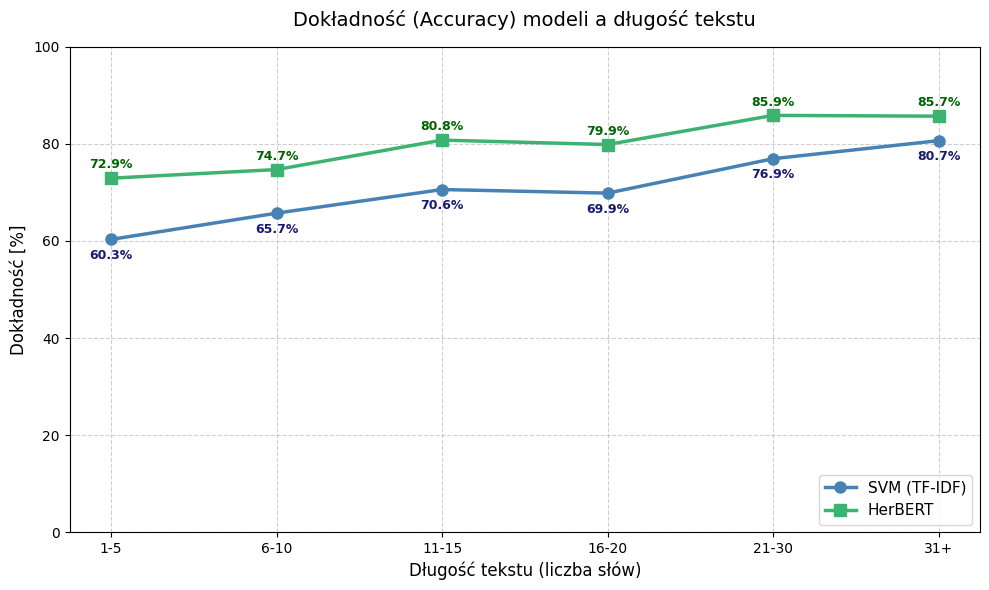


Szczegółowa tabela wyników:


,Przedzial_dlugosci,Liczba_tekstow,Acc_SVM,Acc_HerBERT
0,1-5,872,60.3,72.9
1,6-10,3540,65.7,74.7
2,11-15,1915,70.6,80.8
3,16-20,939,69.9,79.9
4,21-30,616,76.9,85.9
5,31+,119,80.7,85.7


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Obliczamy długość każdego tekstu w słowach
results_df['Dlugosc_w_slowach'] = results_df['Tekst'].apply(lambda x: len(str(x).split()))

# Tworzymy logiczne koszyki
bins = [0, 5, 10, 15, 20, 30, 100]
labels = ['1-5', '6-10', '11-15', '16-20', '21-30', '31+']
results_df['Przedzial_dlugosci'] = pd.cut(results_df['Dlugosc_w_slowach'], bins=bins, labels=labels)

# Grupujemy dane i obliczamy Accuracy (średnią poprawnych trafień) dla obu modeli
accuracy_by_length = results_df.groupby('Przedzial_dlugosci', observed=False).agg(
    Liczba_tekstow=('Tekst', 'count'),
    Acc_SVM=('classic_correct', 'mean'),
    Acc_HerBERT=('transformer_correct', 'mean')
).reset_index()

# Zamieniamy ułamki na procenty
accuracy_by_length['Acc_SVM'] *= 100
accuracy_by_length['Acc_HerBERT'] *= 100

# Rysowanie wykresu
fig, ax = plt.subplots(figsize=(10, 6))

# Wykres liniowy dla modelu klasycznego
ax.plot(accuracy_by_length['Przedzial_dlugosci'], accuracy_by_length['Acc_SVM'],
        marker='o', linestyle='-', color='steelblue', linewidth=2.5, markersize=8, label='SVM (TF-IDF)')

# Wykres liniowy dla HerBERTa
ax.plot(accuracy_by_length['Przedzial_dlugosci'], accuracy_by_length['Acc_HerBERT'],
        marker='s', linestyle='-', color='mediumseagreen', linewidth=2.5, markersize=8, label='HerBERT')

# Kosmetyka wykresu
ax.set_title("Dokładność (Accuracy) modeli a długość tekstu", fontsize=14, pad=15)
ax.set_xlabel("Długość tekstu (liczba słów)", fontsize=12)
ax.set_ylabel("Dokładność [%]", fontsize=12)
ax.set_ylim(0, 100) # Oś Y od 0 do 100%
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='lower right')

# Dodanie wartości procentowych nad punktami (dla HerBERTa)
for i, txt in enumerate(accuracy_by_length['Acc_HerBERT']):
    ax.annotate(f"{txt:.1f}%", (i, accuracy_by_length['Acc_HerBERT'].iloc[i] + 2),
                ha='center', color='darkgreen', fontsize=9, fontweight='bold')

# Dodanie wartości procentowych pod punktami (dla SVM)
for i, txt in enumerate(accuracy_by_length['Acc_SVM']):
    ax.annotate(f"{txt:.1f}%", (i, accuracy_by_length['Acc_SVM'].iloc[i] - 4),
                ha='center', color='midnightblue', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Wyświetlenie tabeli z danymi pod wykresem
print("\nSzczegółowa tabela wyników:")
display(accuracy_by_length.round(1))

## Wnioski końcowe

### Porównanie podejść

**Podejście klasyczne (TF-IDF + SVM/NB):**
- **Zalety:** Krótki czas trenowania oraz predykcji, brak konieczności posiadania akceleratorów graficznych, niska złożoność obliczeniowa.
- **Charakterystyka:** Modele te osiągają dobre wyniki w sytuacjach, gdy teksty zawierają unikalne dla danej dziedziny słowa kluczowe.
- **Ograniczenia:** Duża wrażliwość na problem rzadkości danych przy bardzo krótkich dokumentach. Modele całkowicie ignorują kolejność słów w zdaniu, przez co nie radzą sobie z wyrazami wieloznacznymi, których sens wynika wyłącznie z kontekstu.

**Podejście Transformer (HerBERT):**
- **Zalety:** Zaawansowane reprezentowanie tekstu uwzględniające zależności między słowami. Dzięki tokenizacji model doskonale radzi sobie z bogatą fleksją języka polskiego oraz poprawnie klasyfikuje teksty oparte na synonimach, nawet jeśli dokładne słowa kluczowe nie pojawiły się w zbiorze treningowym.
- **Ograniczenia:** Bardzo wysokie wymagania sprzętowe, znacznie dłuższy proces dostrajania oraz większy koszt pamięciowy i obliczeniowy podczas wdrażania.

### Typowe błędy modeli w klasyfikacji tematycznej

1. **Teksty wielodziedzinowe:** Krótkie wiadomości łączące motywy z różnych obszarów (np. artykuł o budżetach klubów piłkarskich – model klasyczny oparty na wagach słów często błędnie przypisuje kategorię "Ekonomia" zamiast "Sport").

2. **Zjawisko wieloznaczności:** Słowa, które w zależności od kontekstu zmieniają przynależność tematyczną (np. słowo „bramka” w kontekście sieci komputerowych vs w sporcie). HerBERT zazwyczaj poprawnie interpretuje otoczenie takiego słowa, podczas gdy SVM podejmuje decyzję na podstawie globalnej częstotliwości występowania danego tokenu.

3. **Ekstremalny brak kontekstu:** Treści o bardzo ograniczonej długości (np. jednozdaniowe nagłówki, hashtagi). W przypadku braku bezpośrednich słów kluczowych, reprezentacja TF-IDF staje się zbyt uboga, co uniemożliwia klasyfikatorowi liniowemu podjęcie poprawnej decyzji.